# Mori: Educational Chatbot for Data Processing Concepts

## TLG Certification - Data Science PIDA


## Introduction

El procesamiento de datos abarca múltiples disciplinas relacionadas, como la estadística, las matemáticas, el procesamiento de señales y la programación. Adquirir conocimientos en todas estas áreas puede representar un gran desafío, tanto para estudiantes como para personas con experiencia. En este contexto, el uso de herramientas como los chatbots puede ser de gran ayuda para responder dudas y explicar conceptos clave de manera clara y accesible.

Facilitar la comprensión de los conceptos relacionados con el procesamiento de datos, así como agilizar el acceso a sus definiciones, puede ayudar a que los estudiantes se mantengan motivados y enfocados, evitando la distracción o la frustración al enfrentar problemas complejos. Herramientas como GPT, Gemini y Copilot han demostrado ser valiosas para aumentar la productividad durante el desarrollo de proyectos. Del mismo modo, los chatbots educativos especializados pueden convertirse en aliados importantes para el aprendizaje y la exploración autónoma.

## Objetivo

El objetivo de este proyecto es desarrollar una herramienta similar a las mencionadas anteriormente, pero enfocada exclusivamente en responder preguntas relacionadas con definiciones de conceptos vinculados al procesamiento de datos. Este desarrollo puede considerarse un Producto Mínimo Viable (MVP) que sirve como punto de partida para evaluar su potencial.

A través de la implementación de esta solución, se busca analizar su usabilidad y viabilidad, con miras a una futura expansión. Esta expansión contemplaría el aumento del dataset utilizado para entrenar el modelo, así como la incorporación de conceptos pertenecientes a otras áreas del conocimiento.


## Importando Librerias y Cargando Datos Generados

En esta sección se importan y cargan tanto librerías estándar como librerías personalizadas de Python. Estas tienen como propósito principal la extracción, limpieza, procesamiento y análisis estadístico de datos, en función de sus respectivas composiciones.

Por otro lado, los datos utilizados fueron previamente generados mediante el uso de estas mismas librerías, a través de scripts localizados en la carpeta Scripts, accesible desde la raíz de este proyecto.

A continuación, se presenta una breve descripción de los scripts utilizados y los datos que generan:

- **DataGathering.py**<br>
  Este script se encarga de generar el dataset base, compuesto por conceptos y definiciones relacionados con el procesamiento de datos. La información se obtiene mediante técnicas de web scraping aplicadas a diversas páginas web y libros especializados en el área.

- **DataGathering_Wikipedia.py**<br>
    Este script complementa el dataset base utilizando web scraping sobre Wikipedia para extraer definiciones adicionales de los conceptos de interés. Para ello, se implementaron tanto técnicas manuales como el uso de la plataforma de paga SerpAPI, que facilita el acceso estructurado al contenido de Wikipedia.

### Importando Librerias

In [1]:
import os, random, json, nltk, glob, unidecode, re, warnings, torch, spacy, sys
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
from Data_Generation.Wikipedia_DataWrangling import Manual_WikiSearch, SerpAPI_WikiSearch, select1stsentence, RemBadConcepts,  choosing_best_concept
from Data_Generation.Wikipedia_DataWrangling import removing_duplicates, transformer_similarities, remove_parenthesis_complements, translation_function
from transformers import BertTokenizerFast, AutoTokenizer, pipeline, Seq2SeqTrainer, Seq2SeqTrainingArguments, AutoModelForSeq2SeqLM
from Data_Generation.DataCleaning_Functions import BasicData_Cleaning, Descriptions_Standardization, Cleaning_ManualGathered
from Data_Processing.Preprocessing_Functions import Finding_GrammarArticles, Generating_Intents_Questions, HuggingFace_Dataset
from Data_Processing.Preprocessing_Functions import Building_RobustDataset, FromJson2Pandas, Generating_Parafrasis
from Data_Processing.NLP_TLG_Functions import crea_corpus, tokenizer, nube_palabras, nubes_de_palabras
from Data_Visualization.Plotting_Functions import WordsHistograms, WordsFrequencies, EmbeddedWords_Relations, WordsHistograms2
from collections import Counter
from gensim.models import word2vec
from datasets import Dataset, load_from_disk
import pandas as pd
import numpy as np
import regex as re
import seaborn as sns
import matplotlib.pyplot as plt
# Obtener la ruta del notebook actual
notebook_path = os.getcwd()
project_root = os.path.abspath(os.path.join(notebook_path, ".."))
%matplotlib inline

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Tecuhtli\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Tecuhtli\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Tecuhtli\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Carga de Archivos Base

Los datos utilizados para el entrenamiento del chatbot fueron obtenidos mediante técnicas de web scraping y a partir de libros de acceso libre en formato PDF, todos relacionados con temas de análisis y procesamiento de datos.

***Generación de sinónimos y representaciones alternas***

Durante el desarrollo de este proyecto se procesaron cientos de conceptos relacionados con el procesamiento de datos. Con el objetivo de agilizar, estandarizar y generalizar la forma en que estos conceptos pueden ser consultados por los usuarios, se generó un diccionario de sinónimos en Python. En este diccionario, los sinónimos representan traducciones o formas alternativas de referirse a los conceptos.

Este diccionario se utiliza para generar una columna adicional en los datasets creados, la cual contiene definiciones alternas de ciertos conceptos clave. En los casos en que un concepto no se encuentre aún en el diccionario, se utiliza Google Translate para obtener una representación alternativa, la cual se agrega al diccionario de sinónimos para su uso futuro y así acelerar la generación de nuevos datasets.

In [2]:
path = os.path.join(os.getcwd(), 'Data_Generation', 'Data', 'Dictionary', 'synonyms_dict.json')

# Cargar el diccionario desde el archivo JSON
with open(path, "r", encoding="utf-8") as archivo:
    synonyms = json.load(archivo)

print('Size synonyms: ', len(synonyms.keys()))

Size synonyms:  1499


#### Componentes principales del scrip DataGathering.py

***Extracción desde páginas Web***

El script recopila información desde páginas web específicas definidas dentro del mismo archivo. Como resultado, se genera un DataFrame de Pandas conformado por conceptos y preguntas relacionadas con el procesamiento de datos.

In [4]:
path = os.path.join(os.getcwd(), 'Data_Generation', 'Data', 'Results', 'Webscraping_Concepts.csv')
df_web = pd.read_csv(path, index_col=False)
print('shape: ', df_web.shape)
display(df_web.sample(20).head())

shape:  (676, 4)


,concepto,descripcion,concept,source
532,paso,Un pase hacia adelante y un pase hacia atrás d...,step,developers.google.com
132,discriminado,Un sistema que determina si los ejemplos son r...,discriminator,developers.google.com
20,realidad aumentada,Una tecnología que superpone una imagen genera...,augmented reality,developers.google.com
317,factorización de matriz,"En matemáticas, un mecanismo para encontrar la...",matrix factorization,developers.google.com
272,l1 regularización,Un tipo de regularización que penaliza los pes...,l1 regularization,developers.google.com


***Extracción desde libros en PDF***

También se extrae información de libros de texto de acceso libre en formato PDF. Los datos obtenidos se almacenan en un DataFrame con dos columnas: conceptos y definiciones, ambos enfocados en temas de procesamiento de datos.

In [5]:
path = os.path.join(os.getcwd(), 'Data_Generation', 'Data', 'Results', 'AIBooks_Concepts.csv')
df_pdf = pd.read_csv(path, index_col=False)
df_pdf = df_pdf[df_web.columns]
print('shape: ', df_pdf.shape)
display(df_pdf.sample(20).head())

shape:  (353, 4)


,concepto,descripcion,concept,source
131,google cloud automl,Google es uno de los pioneros de las herramien...,google cloud automl,book2
23,nearest neighbor,"Es un algoritmo, que ha sido ampliamente utili...",nearest neighbor,book1
297,índice de precios de paasche,Es un número que describe la relación exitente...,paasche price index,book4
217,map,Como su nombre lo indica es quien se encarga b...,map,book3
6,internet de las cosas,Es un concepto que se refiere a la interconexi...,internet of things,book1


***Datos adicionales generados con ChatGPT***

Con el fin de contar con una base de datos más robusta para esta primera entrega del MVP, se generó un set adicional de datos utilizando ChatGPT. Esta información complementaria abarca diversos términos y categorías relacionadas con el procesamiento de datos.
Los archivos correspondientes pueden encontrarse en el siguiente directorio dentro del proyecto:
*/Data_Generation/Data/GPT/*

In [6]:
path = os.path.join(os.getcwd(), 'Data_Generation', 'Data', 'Results', 'GPT_Concepts.csv')
df_GPT = pd.read_csv(path, index_col=False)
df_GPT.rename(columns={"Concepto":"concepto", 'Descripción':'descripcion', 'Source':'source'}, inplace=True)
df_GPT = df_GPT[df_web.columns]
print('shape: ', df_GPT.shape)
display(df_GPT.sample(20).head())

shape:  (633, 4)


,concepto,descripcion,concept,source
396,part of speech tagging,Asignación de etiquetas gramaticales a las pal...,part of speech tagging,GPT
26,data warehouse,Sistema para almacenar y analizar grandes cant...,data warehouse,GPT
312,limpieza de datos,Proceso de identificar y corregir problemas en...,data cleaning,GPT
514,bots de software,Programas diseñados para realizar tareas espec...,software bots,GPT
87,sesgo del investigador,Sesgo que ocurre cuando las expectativas del i...,researcher's bias,GPT


***Unificación y almacenamiento***

Finalmente, los DataFrames generados en los pasos anteriores se concatenan y se almacenan en el siguiente directorio, tomando como referencia la ubicación de este notebook:
    */Data_Generation/Data/Results/AI_Concepts.csv*

In [7]:
# Concatenating the generated concepts/definitions dataframes
df_base = pd.concat([df_web, df_pdf, df_GPT], ignore_index=True, sort=False)
df_base.to_csv(os.path.join(os.getcwd(), 'Data_Generation', 'Data', 'Results', 'AIConcepts_Base.csv'), index=False)
print('shape: ',df_base.shape)
display(df_base.sample(20).head())

shape:  (1662, 4)


,concepto,descripcion,concept,source
1546,automatización basada en reglas,Automatización de tareas que siguen reglas pre...,rules -based automation,GPT
1656,gráficos dinámicos,Gráficos que permiten actualización en tiempo ...,dynamic charts,GPT
515,ajuste de inmediato suave,Una técnica para ajustar un modelo de lenguaje...,soft prompt tuning,developers.google.com
253,en condición establecida,"En un árbol de decisión, una condición que pru...",in set condition,developers.google.com
885,hadoop distribuido,Es el funcionamiento coordinado en un clúster ...,distributed hadoop,book3


#### Resumen de conceptos obtenidos mediante web scraping

A continuación, se presenta un resumen del dataset base generado, incluyendo la cantidad de conceptos y definiciones que lo componen, así como las fuentes de donde fueron extraídos. Adicionalmente, se muestra la distribución de las definiciones incluidas en este dataset base, en función del número de tokens que conforman a cada una de ellas. Esta métrica permite tener una idea de la longitud, comportamientos y complejidad promedio del contenido recopilado. 

***Resument del dataset base***


In [8]:
pd.DataFrame(df_base.groupby('source').concepto.count()).T

source,GPT,book1,book2,book3,book4,developers.google.com,iaarbook.github.io
concepto,633,50,90,91,122,624,52


***Comportamiento de las definiciones obtenidas***

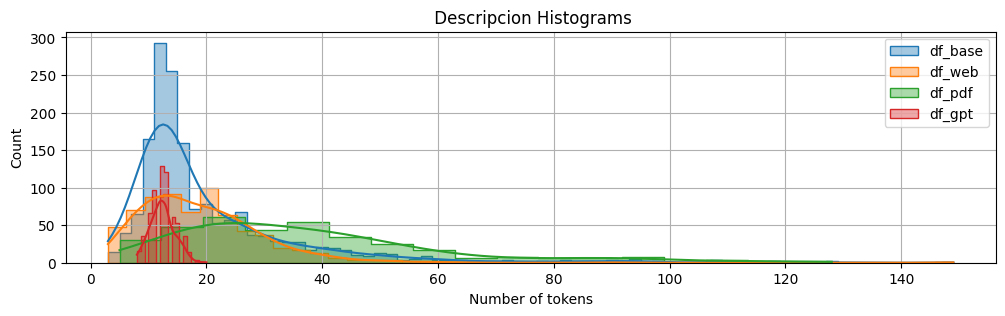

In [8]:
WordsHistograms([df_base, df_web, df_pdf, df_GPT],  'descripcion', ['df_base', 'df_web', 'df_pdf', 'df_gpt'],type_='tokens', figsize=(12,3))

### Carga de archivos complementarios

Además del dataset base generado, se aplicaron técnicas de web scraping para recopilar información complementaria desde Wikipedia, enfocándose en los distintos conceptos que forman parte del conjunto de datos original.

El objetivo de esta etapa es incorporar múltiples definiciones por concepto, así como depurar aquellas definiciones problemáticas o poco representativas. La implementación de esta tarea se realizó mediante el script DataGathering_Wikipedia.py, cuyas funcionalidades principales se describen a continuación:


***Carga de archivos obtenidos desde Wikipedia***

Se utilizaron técnicas personalizadas de web scraping para extraer información relacionada con los conceptos que forman parte del dataset base. Estas técnicas fueron aplicadas sobre la plataforma de Wikipedia, permitiendo realizar búsquedas automatizadas y obtener definiciones relevantes para cada concepto. El archivo generado contiene únicamente aquellos conceptos cuya definición fue encontrada exitosamente mediante estas búsquedas. La extracción se realizó utilizando métodos manuales de scraping desarrollados para este proyecto, con el fin de garantizar mayor control y precisión sobre los datos obtenidos.

In [9]:
path = os.path.join(os.getcwd(), 'Data_Generation', 'Data', 'Wikipedia', 'WikiConcepts_Manual.csv')
df_wiki1 = pd.read_csv(path, index_col=False)
print('shape: ',df_wiki1.shape)
display(df_wiki1.sample(20).head())

shape:  (665, 4)


,concepto,descripcion,concept,source
285,hadoop,Apache Hadoop ( /Həˈduːp /) es una colección d...,hadoop,wikipedia.org
419,media aritmética,"En matemáticas y estadísticas, la media aritmé...",arithmetic mean,wikipedia.org
471,consistencia de datos,La inconsistencia de los datos se refiere a si...,data consistency,wikipedia.org
588,bases de datos,Una base de datos (del inglés: database) se en...,databases,wikipedia.org
603,seguridad,Seguridad (del latín securitas) cotidianamente...,security,wikipedia.org


***Carga de archivos obtenidos desde Wikipedia usando SerpAPI***

Además del web scraping personalizado utilizado para obtener definiciones de los conceptos del dataset base, se recurrió al uso de la plataforma SerpAPI para complementar la recopilación de información. Esta herramienta fue especialmente útil para aquellos conceptos cuyas definiciones no pudieron ser extraídas directamente desde Wikipedia mediante scraping convencional.

Para aumentar la probabilidad de obtener resultados relevantes, se utilizaron diversas palabras clave que acompañaban cada búsqueda en Wikipedia a través de SerpAPI. Como resultado, se generaron múltiples archivos con nombres del tipo WikkiConcepts_SerpAPI_X.csv, donde cada archivo corresponde a un conjunto distinto de palabras clave utilizadas durante las búsquedas.

In [10]:
path = os.path.join(os.getcwd(), 'Data_Generation', 'Data', 'Wikipedia', 'WikiConcepts_SerpAPI1.csv')
df_wiki2a = pd.read_csv(path, index_col=False)
df_wiki2a.loc[:, 'source'] = "Wiki_SerpAPI"
path = os.path.join(os.getcwd(), 'Data_Generation', 'Data', 'Wikipedia', 'WikiConcepts_SerpAPI2.csv')
df_wiki2b = pd.read_csv(path, index_col=False)
df_wiki2b.loc[:, 'source'] = "Wiki_SerpAPI"
print('shape df_wiki2a: ',df_wiki2a.shape, 'shape df_wiki2b: ',df_wiki2b.shape)

df_wiki2a = df_wiki2a[~df_wiki2a.concepto.isin(df_wiki1.concepto.tolist())]
df_wiki2a.reset_index(inplace = True, drop = True)
df_wiki2b = df_wiki2b[~df_wiki2b.concepto.isin(df_wiki1.concepto.tolist())]
df_wiki2b.reset_index(inplace = True, drop = True)
print('shape df_wiki2a: ',df_wiki2a.shape, 'shape df_wiki2b: ',df_wiki2b.shape)

display(df_wiki2a.sample(20).head())

shape df_wiki2a:  (975, 3) shape df_wiki2b:  (685, 3)
shape df_wiki2a:  (941, 3) shape df_wiki2b:  (660, 3)


,concepto,descripcion,source
844,reentrenamiento automático basado en feedback,La retroalimentación positiva (exacerbación de...,Wiki_SerpAPI
869,automatización asistida,La fabricación asistida por computadora (CAM) ...,Wiki_SerpAPI
643,escalabilidad de modelos,MLOps o ML Ops es un paradigma que tiene como ...,Wiki_SerpAPI
393,clasificación de los pgm,"En la música, el ruido es descrito como un son...",Wiki_SerpAPI
359,interfaz-cerebro-computadora,"Una interfaz cerebral -compuidad (BCI), a vece...",Wiki_SerpAPI


#### Resumen de conceptos obtenidos mediante web scraping desde Wikipedia

A continuación, se presenta la distribución de definiciones asociadas a conceptos relacionados con el procesamiento de datos, extraídas desde Wikipedia mediante web scraping personalizado y mediante el uso de SerpAPI. En el caso de las distribuciones generadas con SerpAPI, cada una corresponde a una búsqueda realizada con un conjunto específico de palabras clave, lo que permite comparar cómo varía la cantidad y longitud de las definiciones según los términos utilizados en las consultas.

De forma complementaria, y con el objetivo de analizar las diferencias en el comportamiento y características de las definiciones obtenidas, se incluyen también la distribucion correspondiente a el dataset base, generado a partir de múltiples fuentes iniciales.

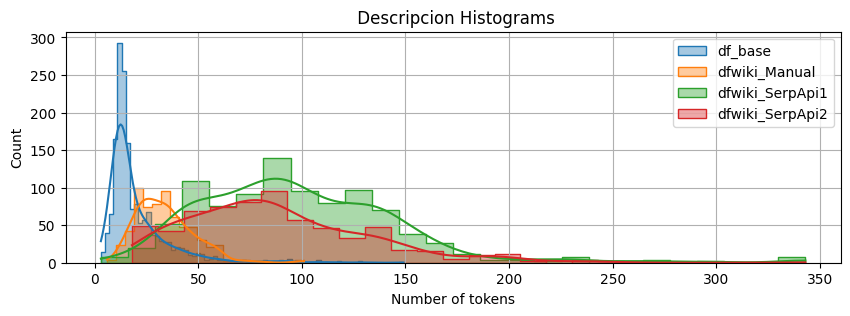

In [11]:
WordsHistograms([df_base, df_wiki1, df_wiki2a, df_wiki2b],  'descripcion', ['df_base', 'dfwiki_Manual', 'dfwiki_SerpApi1', 'dfwiki_SerpApi2'],type_='tokens', figsize=(10,3))

## Procesamiento de datos (Data Wrangling)

En esta sección se presenta el proceso de limpieza y estandarización de la información recolectada, con el fin de permitir su análisis adecuado y facilitar su uso en la generación de un chatbot. Estas tareas son fundamentales para garantizar la calidad del dataset y, por ende, la calidad de las respuestas generadas por el modelo. La limpieza de datos consiste principalmente en la eliminación de párrafos incompletos, irrelevantes o poco claros, los cuales podrían afectar negativamente la comprensión del modelo o introducir ruido en el entrenamiento.

Por otro lado, la estandarización se aplica para asegurar una estructura gramatical coherente en las definiciones, lo cual es esencial para generar respuestas naturales. Además, este proceso también incluye la eliminación de conceptos cuya definición no cumple con un número mínimo o esperado de palabras o tokens.

### Limpieza de Datos

La limpieza de datos se aplica de forma diferenciada según el origen del dataset. En particular:

- **df_wiki2X:**<br> Representa los datasets generados a partir de conceptos y definiciones obtenidos mediante la herramienta SerpAPI, aplicando búsquedas específicas con palabras clave en Wikipedia.

- **df_wiki1:**<br> Contiene conceptos y definiciones recopilados mediante la implementación de técnicas personalizadas de web scraping aplicadas directamente sobre Wikipedia.

- **df_base:**<br> Corresponde al dataset base, conformado por definiciones obtenidas desde diversas fuentes, incluyendo libros de acceso libre y páginas web especializadas.

- ***Reducción de descripciones obtenidas: selección del primer párrafo***

Para las definiciones extraídas mediante SerpAPI, se aplicó una estrategia de limpieza orientada a seleccionar únicamente el primer párrafo de cada definición. Esto con el fin de reducir redundancias, eliminar contenido irrelevante y asegurar respuestas más concisas y útiles.

Este proceso se realizó utilizando las librerías regex y pandas, junto con reglas fijas para corregir ciertos errores gramaticales recurrentes presentes en los textos. La selección del primer párrafo se basa en patrones estructurales del texto extraído desde Wikipedia, priorizando claridad y precisión.

In [12]:
print(df_base.shape, df_wiki1.shape, df_wiki2a.shape, df_wiki2b.shape)
df_wiki2a = select1stsentence(df_wiki2a)
df_wiki2b = select1stsentence(df_wiki2b)

(1662, 5) (665, 5) (941, 4) (660, 4)


- ***Eliminación de conceptos erróneos***

El siguiente paso consiste en eliminar conceptos obtenidos mediante SerpAPI que no cumplen con el comportamiento esperado. Esto incluye aquellos que contienen frases específicas previamente definidas y que no están relacionadas con el procesamiento de datos.

Asimismo, se realiza la corrección de palabras mal escritas que fueron identificadas tras el análisis de los libros utilizados como fuente, corrigiendo errores comunes de escritura o erratas presentes en el contenido original.

In [13]:
df_wiki2a,_,_ = RemBadConcepts(df_wiki2a, None, True)
df_wiki2b,_,_ = RemBadConcepts(df_wiki2b, None, True)

print(df_base.shape, df_wiki1.shape, df_wiki2a.shape, df_wiki2b.shape)

(1662, 5) (665, 5) (911, 4) (638, 4)


#### Comportamiento de las descripciones tras la limpieza

A continuación, se presentan las distribuciones de las definiciones extraídas, todas relacionadas con el procesamiento de datos. Se puede observar un comportamiento más uniforme en las definiciones obtenidas desde Wikipedia, especialmente tras la limpieza, en comparación con las definiciones que conforman el dataset base, el cual fue generado a partir de diversas fuentes adicionales.

Este análisis permite visualizar cómo varía la longitud y estructura de las definiciones según su origen, lo cual resulta útil para evaluar la consistencia del dataset final utilizado en el entrenamiento del chatbot.

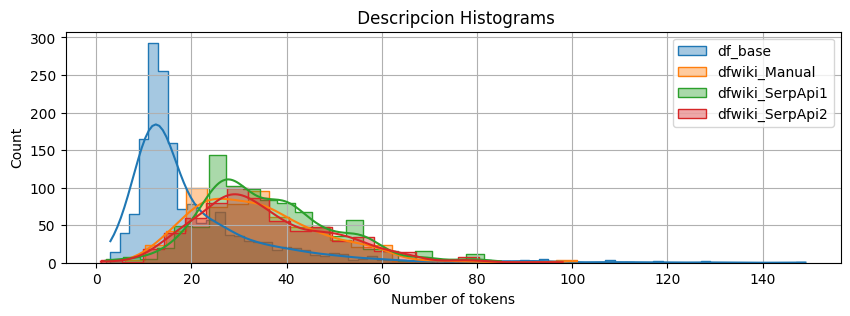

In [14]:
WordsHistograms([df_base, df_wiki1, df_wiki2a, df_wiki2b],  'descripcion', ['df_base', 'dfwiki_Manual', 'dfwiki_SerpApi1', 'dfwiki_SerpApi2'],type_='tokens', figsize=(10,3))

### Procesamiento de descripciones obtenidas

Además de aplicar limpieza a los datos, es necesario descartar o filtrar información que no esté relacionada con el campo de interés. Esto es especialmente común cuando los datos se obtienen mediante herramientas de web scraping, ya que no se tiene un control total sobre el contenido extraído, particularmente cuando este proviene de resultados de búsqueda en motores como Google o DuckDuckGo, en lugar de fuentes específicas.

El enfoque principal para este proceso de filtrado semántico se basa en el uso de transformers para medir la similitud entre conceptos y definiciones especificos. Esta técnica permite comparar definiciones obtenidas automáticamente con aquellas del dataset base del proyecto, que actúan como referencia. De este modo, se eliminan aquellas definiciones que presentan baja similitud semántica, ya que se considera que no están suficientemente relacionadas con los conceptos del dominio objetivo.

***Seleccionando la mejor definicion encontrada desde Wikipedia (SerpAPI)***

El primer paso en el proceso de filtrado consiste en determinar cuál definición, entre aquellas obtenidas mediante SerpAPI, presenta mayor similitud semántica con las definiciones contenidas en el dataset base, siempre y cuando se refieran al mismo concepto.

Para esta tarea se utilizó el modelo *paraphrase-multilingual-MiniLM-L12-v2*, el cual está especialmente diseñado para medir similitud entre frases. Uno de sus usos clave es precisamente el filtrado de definiciones irrelevantes. Esto se logra mediante el uso de vectores de embeddings generados por el modelo, los cuales capturan el significado de cada definición. Posteriormente, se calcula la similitud coseno entre los embeddings de cada definición candidata y la correspondiente en el dataset base. Aquella con mayor similitud es seleccionada como la más representativa.

In [15]:
df_wiki2 = choosing_best_concept(df_base, df_wiki2a, df_wiki2b)

Processing: 100%|██████████████████████████████████████████████████| 911/911 [58:14<00:00,  3.84s/row]


##### Guardando las mejores definiciones encontradas desde Wikipedia

In [16]:
path = os.path.join(os.getcwd(), 'Data_Generation', 'Data', 'Wikipedia', 'WikiConcepts_SerpAPI.csv')
df_wiki2.to_csv(path, index=False)

***Filtrado de definiciones de Wikipedia con baja similitud respecto al dataset base***

Luego de generar un dataset unificado que combina las definiciones extraídas mediante SerpAPI, se procede al siguiente paso del proceso de limpieza. Este paso consiste en comparar las definiciones del dataset base con las definiciones del dataset unificado, considerando únicamente aquellas que corresponden al mismo concepto.

A diferencia del caso anterior, donde se seleccionaba la mejor definición entre varias candidatas, en este caso se utiliza un valor umbral de similitud semántica. Si la similitud entre la definición de Wikipedia y la del dataset base no supera dicho umbral, se considera que la definición no es suficientemente representativa y, por lo tanto, es descartada o filtrada del conjunto de datos.

In [17]:
idxs2keep, idxs2rem, sims, bad_sims = transformer_similarities(df_base, df_wiki2, thre=.3)
df_wiki2 = df_wiki2.loc[idxs2keep]
df_wiki2.reset_index(inplace = True, drop = True)

print(df_wiki2.shape)

Processing: 100%|██████████████████████████████████████████████████| 911/911 [38:07<00:00,  2.51s/row]

(736, 4)


##### Guardando las mejores definiciones encontradas desde Wikipedia

In [18]:
path = os.path.join(os.getcwd(), 'Data_Generation', 'Data', 'Wikipedia', 'WikiConcepts_SerpAPI_Similar.csv')
df_wiki2.to_csv(path, index=False)

##### Actualizando dictionario de sinonimos para mejorar resultados usando webscraping

In [19]:
print('Size synonyms: ', len(synonyms.keys()))
df_wiki2.loc[:, 'concept'] = df_wiki2['concepto'].map({v: k for k, v in synonyms.items()})

for idx in df_wiki2.loc[df_wiki2.index[df_wiki2.concept.isna()]].index:
    df_wiki2.loc[idx, 'concept'] = translation_function(df_wiki2.loc[idx, 'concepto'], english=True)
    synonyms[df_wiki2.loc[idx, 'concept'].lower()] = df_wiki2.loc[idx, 'concept'].lower()
df_wiki2.loc[:, 'concept'] = df_wiki2.concept.str.lower()

print('Size synonyms: ', len(synonyms.keys()))

Size synonyms:  1499
Size synonyms:  1789


***Creación del dataset de definiciones generadas desde Wikipedia***

Después de generar un dataset unificado con las definiciones extraídas mediante SerpAPI, este se concatena con el dataset obtenido a partir de web scraping personalizado sobre Wikipedia. El resultado es un conjunto de definiciones complementarias, provenientes exclusivamente de Wikipedia, que se utilizará para enriquecer el dataset base generado a partir de otras fuentes distintas a dicha plataforma.

In [20]:
df_wiki = pd.concat([df_wiki1, df_wiki2], ignore_index=True, sort=False)

print(df_wiki.shape)

(1401, 5)


#### Resumen de conceptos obtenidos mediante web scraping desde Wikipedia

A continuación, se presenta un resumen de los datos procesados, incluyendo la cantidad de ejemplos que conforman el dataset unificado generado a partir de información extraída desde Wikipedia, así como el método de recolección utilizado: ya sea mediante SerpAPI o a través de web scraping personalizado.

De forma adicional, se muestra la distribución de las definiciones que componen este dataset de Wikipedia, comparada con la distribución de definiciones del dataset base.
Esta comparación permite observar diferencias en el comportamiento y estructura de las definiciones entre ambas fuentes, lo cual puede tener un impacto en la etapa de entrenamiento y generación de respuestas del chatbot.

- **Resumen**

In [21]:
pd.DataFrame(df_wiki.groupby('source').concepto.count()).T

source,Wiki_SerpAPI,wikipedia.org
concepto,736,665


- **Comparación de distribuciones: Dataset Base vs. Wikipedia**

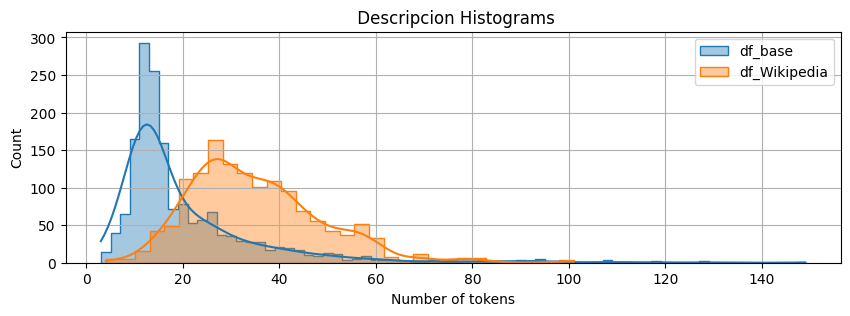

In [22]:
WordsHistograms([df_base, df_wiki],  'descripcion', ['df_base', 'df_Wikipedia'],type_='tokens', figsize=(10,3))

##  Consolidación de conceptos clave sobre procesamiento de datos

En esta sección se presenta la consolidación de un conjunto de conceptos clave relacionados con el procesamiento de datos. Estos conceptos fueron extraídos a partir de fuentes especializadas, incluyendo glosarios temáticos disponibles en línea y textos bibliográficos enfocados directamente en el área. La consolidación se realizó integrando definiciones adicionales a los conceptos base previamente recolectados. Estas definiciones complementarias fueron obtenidas desde Wikipedia, utilizando tanto web scraping personalizado como el servicio comercial SerpAPI.

Dado que algunas definiciones contenían información fuera del dominio de interés, se aplicó un proceso de filtrado semántico. Este permitió excluir definiciones no relevantes mediante el uso de modelos tipo Transformer, comparando su similitud con el dataset base. El resultado de este proceso es un dataset enriquecido, que agrupa múltiples definiciones por concepto, proporcionando una base de conocimiento procesada y posiblemente lista para ser utilizada en el entrenamiento del chatbot.

- ***Cargando los conceptos y definiciones de referencia, y los complementarios***

In [23]:
path = os.path.join(os.getcwd(), 'Data_Generation', 'Data', 'Results', 'Concepts_Base.csv')
df_base.to_csv(path, index=False)
path = os.path.join(os.getcwd(), 'Data_Generation', 'Data', 'Results', 'Concepts_Wikipedia.csv')
df_wiki.to_csv(path, index=False)

### Creando el Dataset General

Este dataset constituye la base consolidada del conocimiento que alimentará a Mori. Sin embargo, aún no puede considerarse definitivo, requiere una curaduría cuidadosa que asegure la calidad y coherencia de cada concepto incluido. Al tratarse de una herramienta de aprendizaje, cada definición debe ser confiable, clara y alineada con el propósito de enseñar.

In [24]:
df_concepts = pd.concat([df_base, df_wiki], ignore_index=True, sort=False)
df_concepts.reset_index(inplace = True, drop = True)
display(df_concepts.sample(5))

,concepto,descripcion,concept,source,num_tokens
818,información,Es el conjunto de datos que han sido procesado...,information,book3,36
1019,variable continua,Es una variable cuantitativa. es la caracterí...,continuous variable,book4,25
1882,regresión lineal,"En estadísticas, la regresión lineal es un mod...",linear regression,wikipedia.org,35
1849,internet de las cosas,Internet de las cosas (IoT) describe dispositi...,internet of things,wikipedia.org,40
971,índice agregativo,Es aquel que expresa la variación de un conjun...,aggregative index,book4,13


***Eliminación de conceptos duplicados***

A pesar de los procesos de limpieza y curaduría aplicados previamente, aún pueden existir conceptos duplicados con definiciones idénticas. Para evitar un desbalance en el dataset de entrenamiento y reducir el riesgo de sobreajuste a definiciones repetidas, estos casos son detectados y eliminados. Este paso asegura que cada concepto en el dataset esté representado de forma única y significativa, manteniendo la diversidad y calidad del conjunto de datos.

In [25]:
df_concepts.drop_duplicates(['concepto', 'concept', 'descripcion'],inplace=True, ignore_index=True)

#### Resumen de la conformación y comportamiento del dataset general

En esta subsección se presenta un resumen de la conformación y el comportamiento del dataset general generado. La conformación hace referencia a la cantidad total de conceptos que integran el dataset, segmentados según las fuentes procesadas.

Por otro lado, el comportamiento se analiza a partir de la distribución de las definiciones, utilizando como métrica principal la cantidad de tokens que componen a cada una. Este análisis permite observar variaciones en la longitud y estilo de las definiciones según su origen, lo cual es relevante para evaluar la coherencia del conjunto de datos final.

- **Conformación del dataset General**

In [26]:
pd.DataFrame(df_concepts.groupby('source').concepto.count()).T

source,GPT,Wiki_SerpAPI,book1,book2,book3,book4,developers.google.com,iaarbook.github.io,wikipedia.org
concepto,633,701,50,90,91,122,624,52,529


- **Comportamiento del dataset General**

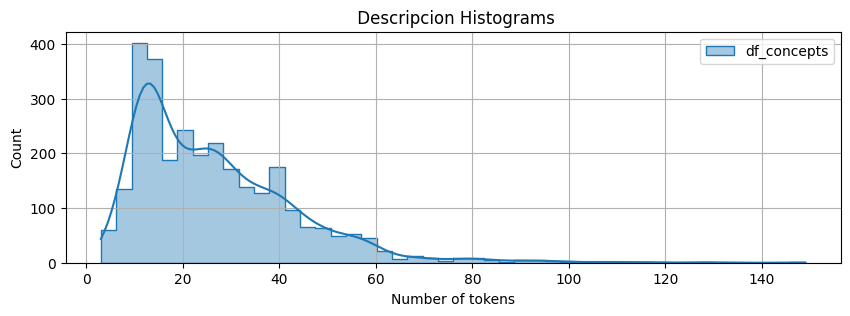

In [27]:
WordsHistograms([df_concepts],  'descripcion', ['df_concepts'],type_='tokens', figsize=(10,3))

##### Guardando el dataset de conceptos y definiciones Consolidado

In [28]:
path = os.path.join(os.getcwd(), 'Data_Generation', 'Data', 'Results')
df_concepts.to_csv(os.path.join(path, "DataScience_Concepts.csv"), index=False)

##  Exploración del comportamiento de los conceptos y definiciones generadas

Una vez generado el dataset general que dará origen a Mori, el asistente especializado en procesamiento de datos, es necesario validar la información recopilada para evaluar su viabilidad como base de entrenamiento. Esta validación se lleva a cabo mediante el análisis de corpuses construidos a partir de los conceptos y definiciones que conforman dicho dataset. A través de estos análisis se busca identificar patrones, redundancias y posibles inconsistencias en el contenido.

Los análisis implementados incluyen:

- Creación de corpuses
- Análisis de frecuencia de palabras, una vez que los corpuses han sido tokenizados.
- Relaciones semánticas entre conceptos, mediante embeddings generados a partir del corpus.
- Representaciones visuales, como nubes de palabras (wordclouds), que permiten observar de forma intuitiva los términos más frecuentes en el conjunto.

***Creación de corpuses***

In [29]:
# Generating Corpuses
corpus_conceptos = [crea_corpus(df_concepts['concepto'].map(lambda oracion: tokenizer(oracion)), 'lemmatizer')]
corpus_desc = [crea_corpus(df_concepts['descripcion'].map(lambda oracion: tokenizer(oracion)), 'lemmatizer')]

***Estimación de frecuencias de palabras***

In [ ]:
# Estimating word frequencies
counts_conceptos = Counter(corpus_conceptos[0])
counts_conceptos = {k: v for k, v in sorted(counts_conceptos.items(), key=lambda item: item[1], reverse=True)}
counts_desc = Counter(corpus_desc[0])
counts_desc = {k: v for k, v in sorted(counts_desc.items(), key=lambda item: item[1], reverse=True)}

***Modelado semántico mediante Word2Vec***

In [ ]:
# Creating word2vec models
modelo_conceptos = word2vec.Word2Vec(corpus_conceptos, vector_size=100, window=100, min_count=5)
modelo_desc = word2vec.Word2Vec(corpus_desc, vector_size=100, window=100, min_count=5)

### Análisis de frecuencia de palabras en conceptos y definiciones

En la siguiente figura se muestra la frecuencia de las palabras más comunes que componen los conceptos y definiciones presentes en el dataset utilizado para entrenar el chatbot Mori. Se observa un patrón coherente entre ambos conjuntos, términos como *datos*, *modelo*, *aprendizaje* y *análisis* aparecen con alta frecuencia tanto en los conceptos como en las definiciones. Esto indica que el vocabulario utilizado en el dataset es técnicamente relevante y alineado con el dominio del procesamiento de datos.

Además, en el lado de las definiciones se destacan palabras como *automático*, *conjunto*, *proceso* y *sistema*, lo que sugiere una presencia significativa de definiciones orientadas a explicar estructuras, funciones y metodologías propias del área.

Esta consistencia en el lenguaje contribuye positivamente a que el modelo pueda reconocer patrones semánticos relevantes durante el entrenamiento, y mejora su capacidad para generar respuestas precisas dentro del dominio objetivo.

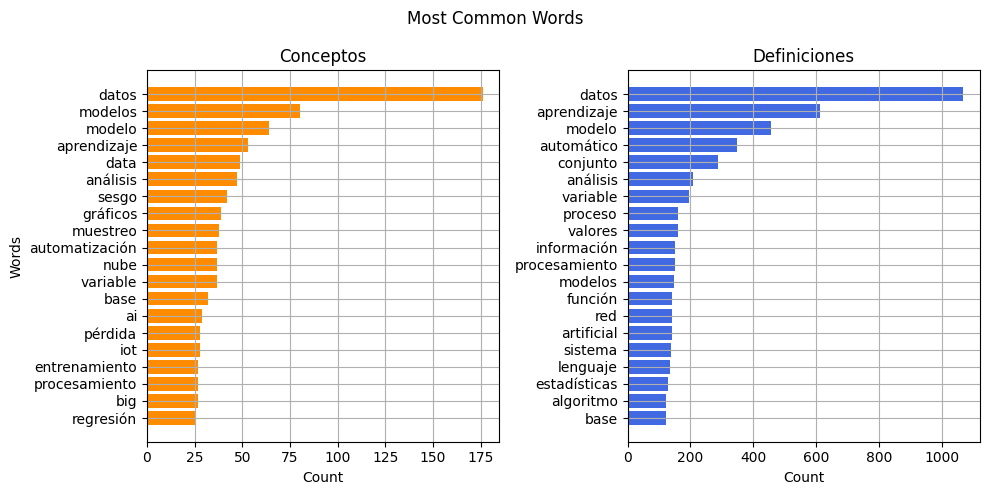

In [30]:
WordsFrequencies(counts_conceptos, counts_desc, 'Conceptos', 'Definiciones', lim_words=20)

### Proyección de vectores de palabras en definiciones

En la siguiente figura se muestra una proyección bidimensional de los vectores de palabras que componen las definiciones utilizadas durante el entrenamiento del chatbot de preguntas y respuestas (Q&A). La visualización fue generada a partir de un modelo de embeddings, reduciendo la dimensionalidad en base a t-SNE para facilitar su interpretación visual.

Se puede observar un patrón cíclico en la distribución espacial de las palabras, lo cual era esperable, ya que muchas de ellas pertenecen a un vocabulario técnico común en el área del procesamiento de datos. Esto refleja cierta coherencia semántica dentro del corpus. No obstante, también se identifican agrupamientos dispersos o aislados, formados por palabras que parecen no guardar una relación clara con el resto del conjunto. Estas palabras podrían considerarse ruido semántico, ya que no necesariamente pertenecen al dominio específico del chatbot.

Este tipo de ruido es importante de atender, ya que puede afectar la calidad del entrenamiento del modelo, al introducir definiciones menos relevantes o inconsistentes. Por ello, este análisis es clave para guiar procesos posteriores de filtrado o refinamiento del vocabulario utilizado en el dataset.

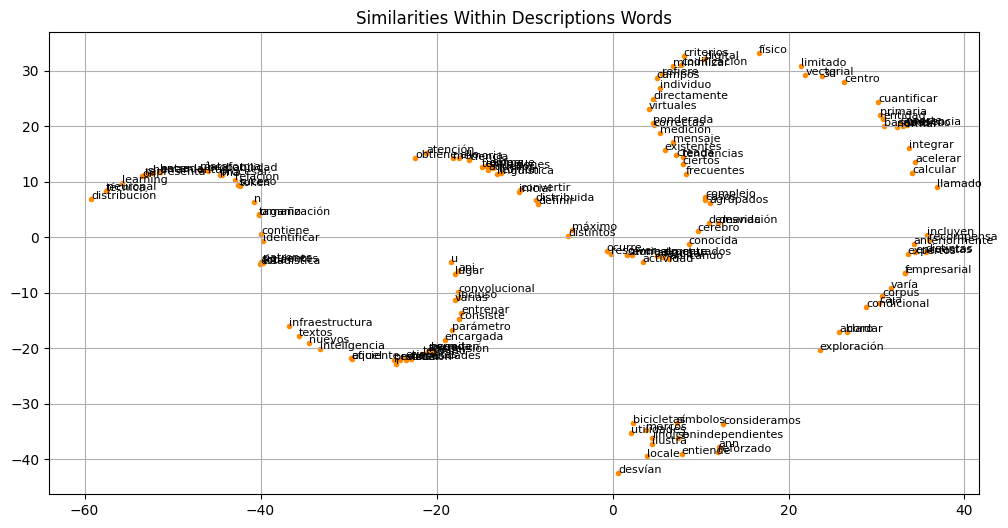

In [33]:
EmbeddedWords_Relations(modelo_desc, 'Similarities within descriptions words', (12,6))

### Representación visual de las palabras en las definiciones

La siguiente figura presenta una visualización alternativa de la frecuencia de palabras que componen las definiciones del dataset. Estas definiciones son utilizadas durante el entrenamiento del chatbot para relacionarse con posibles preguntas realizadas por los usuarios. En esta representación tipo nube de palabras, el tamaño de cada palabra es proporcional a su frecuencia de aparición dentro del corpus. Esta visualización permite identificar rápidamente los términos más comunes, y ofrece una perspectiva intuitiva sobre el vocabulario dominante en el conjunto de definiciones.

Text(0.5, 1.0, 'Word Frequencies for Concepts Descriptions')

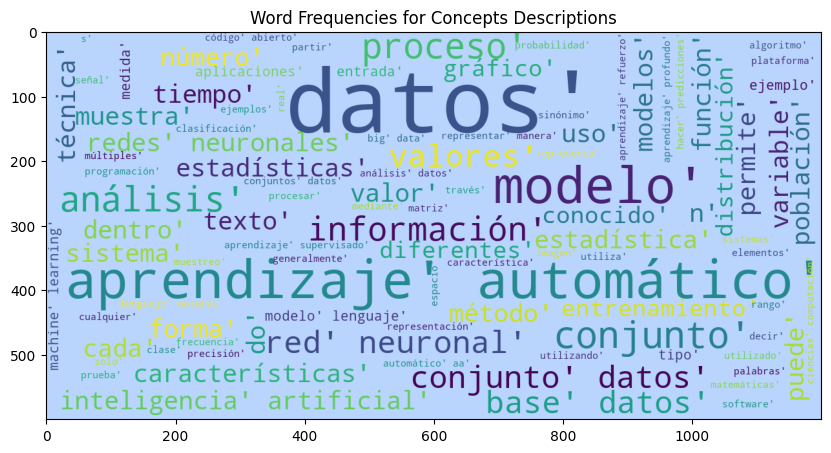

In [34]:
fig, axs = plt.subplots(1,1, figsize=(10,9))  
nube_palabras(corpus_desc, axs, '#b9d5fd')
axs.set_title('Word Frequencies for Concepts Descriptions')

## Análisis de datos curados manualmente

A partir del análisis realizado sobre el dataset general en la sección anterior, se llevó a cabo una curaduría manual con el objetivo de maximizar la calidad y usabilidad de los datos destinados al entrenamiento de Mori. Una de las principales motivaciones para esta revisión fue lo observado en la representación visual de las relaciones semánticas entre palabras, basada en word embeddings. Como se mencionó previamente, si bien es esperable un patrón periódico debido al uso común de cierto vocabulario técnico, se detectaron comportamientos erráticos fuera de ese patrón, lo que sugiere la presencia de palabras no alineadas con el dominio de interés.

Por ello, se procedió a revisar de forma manual los conceptos y definiciones, con lo cual se logró una mejora significativa en la calidad del dataset, como se evidencia en los resultados mostrados a continuación. Esta curaduría no solo fortalece la versión actual de Mori, sino que establece una nueva referencia de calidad que podrá ser utilizada como dataset base confiable en futuras expansiones del modelo, aplicando los métodos automáticos previamente desarrollados.

- ***Leyendo el dataset curado***

In [3]:
# Load the cleaned JSON file 
path = os.path.join(os.getcwd(), 'Data_Generation', 'Data', 'Concepts2Improve', 'Conceptos_Curados_Manualmente.json')
#path = os.path.join(os.getcwd(), 'Data_Generation', 'Data', 'Concepts2Improve', 'Conceptos_Curados_Manualmente_ContextoV2.json')
with open(path, "r", encoding="utf-8") as file:
    data = json.load(file)

print(f'El json curado esta compuesto por {len(data)} preguntas diferentes. Ejemplos de datos curados: ')
data[48:50]

El json curado esta compuesto por 1251 preguntas diferentes. Ejemplos de datos curados: 


[{'input': '¿Qué es la roc curve?',
  'output': 'Relaciona el recall con el ratio de falsos positivos. Es decir relaciona la sensibilidad de nuestro modelo con los fallos optimistas (clasificar los negativos como positivos).'},
 {'input': '¿Qué es el área bajo la curva auc?',
  'output': 'Es una herramienta estadística que mide la probabilidad de que un modelo clasifique correctamente un ejemplo positivo y negativo.'}]

#### Generación de un DataFrame con conceptos, definiciones y artículos gramaticales

Dado que el dataset curado está compuesto por preguntas orientadas a definir conceptos y sus respectivas respuestas, es necesario procesar el archivo JSON que contiene esta información para permitir su análisis y comparación con el dataset general utilizado previamente.

La estructura de este archivo JSON responde al formato de pregunta-respuesta (Q&A), ya que fue utilizada durante el proceso de curaduría y es el formato requerido para el entrenamiento de Mori. En la siguiente celda se transforma dicho archivo JSON en un DataFrame de Pandas, compuesto por tres columnas principales:

- El concepto a definir.
- Su correspondiente definición.
- El artículo gramatical asociado al concepto (por ejemplo, “el”, “la”), necesario para formular preguntas correctamente estructuradas.

In [4]:
preguntas = ['¿Qué es', '¿Qué es', '¿Que es', '¿Qué son', '¿Que son', 'Para qué sirve']
articulos = ['el', 'los', 'la', 'las', 'un', 'una']

df_curated = FromJson2Pandas(data, preguntas, articulos)
print(f'El dataset esta compuesto por {df_curated.shape[0]} diferentes conceptos\n')
df_curated.sample(5)

El dataset esta compuesto por 1251 diferentes conceptos



,concepto,descripcion,contexto,articulo
986,regresión lineal,"Estima los coeficientes de la ecuación lineal,...",[],la
574,model parallelism,Una forma de escalar el entrenamiento o la inf...,[],
1113,procesamiento analítico en línea,Es una tecnología que organiza y analiza grand...,[],el
509,landmark detection,Es una tecnología de visión artificial que uti...,[],
281,impacto dispar,Es una métrica de evaluación de la equidad que...,[],el


### Análisis de la distribución de tokens en respuestas curadas

En la siguiente figura se muestra la distribución de tokens correspondiente a las definiciones curadas que se utilizarán para entrenar el modelo de preguntas y respuestas (Q&A) de Mori. La distribución refleja un comportamiento aproximadamente normal, con una concentración mayor en torno a las 20 palabras por definición. Este comportamiento es más estable y consistente en comparación con la distribución observada en el dataset no curado, presentada en una sección anterior.

Esta mayor regularidad en la longitud de las definiciones sugiere una mejora en la coherencia estructural del dataset, lo cual es favorable para el proceso de entrenamiento del modelo, al reducir la variabilidad innecesaria entre muestras.

C:\Users\Tecuhtli\Developments\Coding\Python\Mori_Development\Notebooks\Data_Visualization\Plotting_Functions.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'num_tokens'] = df[col1].apply(lambda x: nlp(x)).str.len()


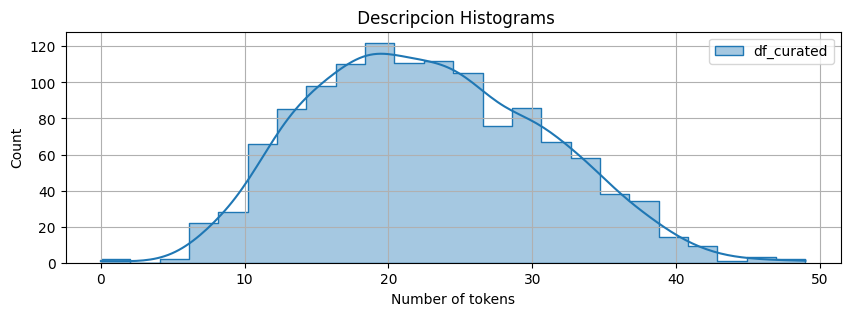

In [5]:
WordsHistograms([df_curated[df_curated.columns[:2]]],  'descripcion', ['df_curated'],type_='tokens', figsize=(10,3))

#### Procesamiento de definiciones para su análisis

Al igual que en el análisis anterior realizado sobre las definiciones del dataset general, en esta etapa se busca generar un modelo de relaciones semánticas mediante embeddings a partir del conjunto de definiciones curadas. Para ello, es necesario construir un corpus textual con las definiciones procesadas, el cual servirá como base para entrenar o aplicar un modelo de embeddings. Este corpus permitirá analizar la estructura semántica de las definiciones y evaluar su coherencia dentro del dominio del procesamiento de datos.

In [6]:
# Generating Corpuses
corpus_desc = [crea_corpus(df_curated['descripcion'].map(lambda oracion: tokenizer(oracion)), 'lemmatizer')]
# Estimating word frequencies
counts_desc = Counter(corpus_desc[0])
counts_desc = {k: v for k, v in sorted(counts_desc.items(), key=lambda item: item[1], reverse=True)}
# Creating word2vec models
modelo_desc = word2vec.Word2Vec(corpus_desc, vector_size=100, window=100, min_count=5)

### Proyección de vectores de palabras en definiciones curadas

Las definiciones que componen el dataset curado fueron procesadas para analizar su comportamiento semántico mediante la proyección de los vectores de palabras (tokens) que las conforman. Esta visualización puede observarse en la siguiente Figura. A diferencia de lo observado en el análisis previo del dataset sin curar, aquí se aprecia una distribución más estable y estructurada de las palabras en el espacio vectorial. Este comportamiento indica una mayor coherencia semántica entre los términos, con agrupamientos más consistentes y relaciones menos erráticas.

Esta mejora es clave para el entrenamiento del modelo Q&A, ya que un vocabulario más estructurado y temáticamente alineado favorece el aprendizaje efectivo. En consecuencia, Mori tendrá mayor capacidad para generar respuestas precisas y comprensibles ante las posibles preguntas formuladas por los usuarios.

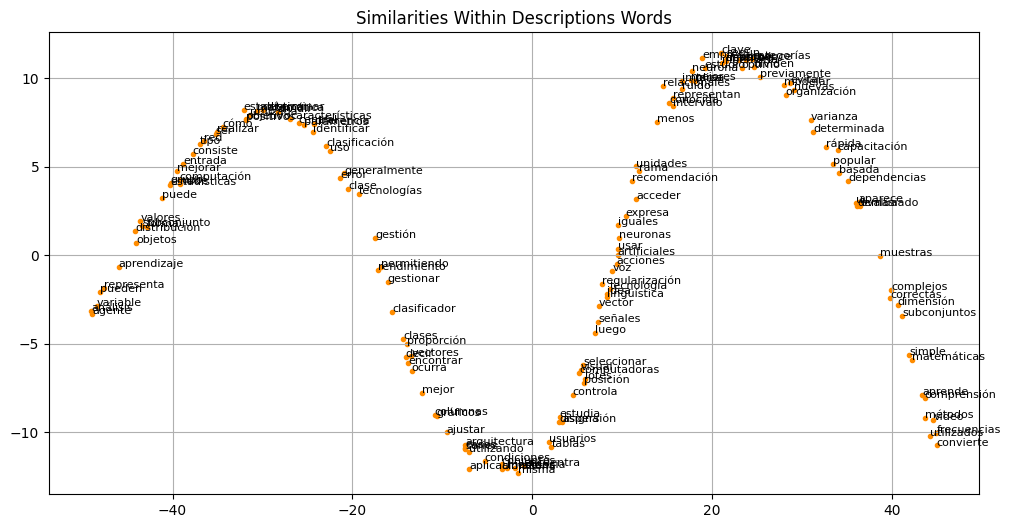

In [8]:
EmbeddedWords_Relations(modelo_desc, 'Similarities within descriptions words', (12,6))

## Aumentando la diversidad de palabras mediante paráfrasis

Una vez finalizado el análisis del dataset curado y validada su calidad para los objetivos de este proyecto, se procede a incrementar la diversidad lingüística de las preguntas utilizadas para entrenar el modelo. Para ello, se generan paráfrasis de las preguntas originales, es decir, diferentes formas de formular una misma consulta sobre un concepto específico. Esta técnica permite ampliar el rango de expresiones que un usuario podría emplear para interactuar con el chatbot, sin alterar el significado subyacente de la pregunta.

Este enriquecimiento tiene como objetivo mejorar la capacidad de generalización del modelo, permitiéndole reconocer variaciones naturales en el lenguaje y ofrecer respuestas precisas, independientemente de cómo esté formulada la pregunta.

### Implementacion de Parafrasis

En la siguiente celda se realiza la implementación del proceso de generación de paráfrasis utilizando las siguientes variables clave:

- **inquiries_templates**<br>
    Esta variable es una lista de tuplas que define las estructuras base para generar paráfrasis. Cada tupla contiene:
    - Una plantilla de pregunta.
    - Un valor booleano que indica si es necesario incluir el artículo gramatical correspondiente al concepto.
    - Una regla de ajuste que permite modificar la estructura en función de si el concepto es singular o plural.

- **df_curated**<br>
    DataFrame de Pandas que contiene el dataset curado de conceptos y definiciones. Además, incluye una columna adicional que indica el artículo gramatical asociado a cada concepto, necesario para construir preguntas correctamente estructuradas en español.


In [19]:
# Diferentes formas en la que preguntara lo mismo, parafrasis
Inquiries_Templates = [('¿Qué es', 'si', '¿Qué son'), ('¿Para qué sirve','si', '¿Para qué sirven'),  ('Explícame el concepto de', 'no', '0'),
                     ('¿Qué entiendes por', 'si', '0'), ('Define el término', 'no', '0')]
# Implementando la parafrasis de preguntas
intents = Generating_Parafrasis(df_curated, Inquiries_Templates)

print("Ejemplos de preguntas con parafrisis generadas: \n")
for intent in intents[48:52]:
    print("intent: ")
    print("    canonical_term: ", intent['canonical_term'])
    print("    input: ", intent['input'])
    print("    output: ", intent['output'], '\n')

Ejemplos de preguntas con parafrisis generadas: 

intent: 
    canonical_term:  aprendizaje activo
    input:  ¿Qué es el aprendizaje activo?
    output:  Es un caso especial de aprendizaje automático en el que un algoritmo de aprendizaje puede interactuar de manera interactiva con un usuario para etiquetar nuevos puntos de datos con las salidas deseadas 

intent: 
    canonical_term:  aprendizaje activo
    input:  ¿Para qué sirve el aprendizaje activo?
    output:  Es un caso especial de aprendizaje automático en el que un algoritmo de aprendizaje puede interactuar de manera interactiva con un usuario para etiquetar nuevos puntos de datos con las salidas deseadas 

intent: 
    canonical_term:  aprendizaje activo
    input:  Explícame el concepto de aprendizaje activo
    output:  Es un caso especial de aprendizaje automático en el que un algoritmo de aprendizaje puede interactuar de manera interactiva con un usuario para etiquetar nuevos puntos de datos con las salidas deseadas 

in

## Análisis de los datasets para el entrenamiento del modelo Q&A

Luego de la generación de paráfrasis, se construyó un dataset adicional orientado al entrenamiento de un modelo Q&A enfocado exclusivamente en el contexto social. Esta decisión responde a la necesidad de que el chatbot cuente con una interfaz amigable y accesible, capaz de facilitar la interacción inicial con los usuarios.

Este componente social permitirá que Mori no solo responda preguntas técnicas, sino que también genere confianza y proporcione una experiencia conversacional fluida desde el primer contacto. Así, el usuario podrá interactuar de forma natural y, posteriormente, formular preguntas relacionadas con temas técnicos del procesamiento de datos, las cuales serán atendidas por el modelo especializado.

En esta sección se analizan los comportamientos finales de los distintos datasets que se utilizarán para entrenar a Mori, abarcando tanto su dimensión social como su dimensión técnica, con el objetivo de garantizar un desempeño equilibrado y coherente en ambos contextos.

##### Cargando los datos que se usaran para entrenar los modelos

In [2]:
# Cargar el archivo JSON
json_path = os.path.join(project_root, 'Data', "Conceptos_Curados_Manualmente_Social.json")
with open(json_path, "r", encoding="utf-8") as file:
    data = json.load(file)

# Convertir en DataFrame

df_social = pd.DataFrame(data)
json_path = os.path.join(project_root, 'Data', "Conceptos_Curados_Manualmente_ContextoV3.json")
with open(json_path, "r", encoding="utf-8") as file:
    data = json.load(file)    

# Convertir en DataFrame
df_tecnico = pd.DataFrame(data)
df_tecnico.drop(index=df_tecnico[df_tecnico.context=='social'].index.tolist(), inplace=True)

print(df_social.shape, df_tecnico.shape)

(140, 4) (5112, 4)


### Analizando la distribución de corpuses de los datasets a utilizar (respuestas)

La siguente Figura presenta la distribución de la longitud (en número de tokens) de las respuestas que conforman los dos datasets que serán utilizados para entrenar a Mori: uno enfocado en el componente técnico y otro en el componente social. Se observa que las respuestas del dataset técnico (color azul) presentan una mayor variabilidad y una longitud promedio significativamente más alta, lo cual es esperable dado que las respuestas técnicas tienden a ser más detalladas, informativas y específicas.

En contraste, las respuestas del dataset social (color naranja) se concentran en un rango más reducido de tokens, reflejando un estilo de comunicación más directo, breve y conversacional. Este comportamiento es coherente con su objetivo: facilitar una interacción inicial amigable con el usuario. Esta diferencia en las distribuciones valida el enfoque de separar los contextos en dos modelos distintos, ya que ambos presentan características lingüísticas y funcionales claramente diferenciadas, lo cual favorecerá el rendimiento y la adecuación del chatbot en cada tipo de interacción.

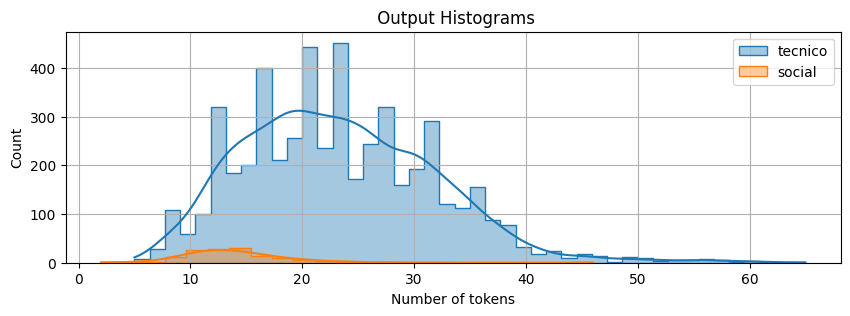

In [3]:
WordsHistograms([df_tecnico, df_social],  'output', ['tecnico', 'social'],type_='tokens', figsize=(10,3))

### Analizando la distribución de palabras

La siguiente figura muestra una visualización comparativa de las palabras más frecuentes en los dos datasets que componen el entrenamiento de Mori: el social (arriba) y el técnico (abajo). Cada nube de palabras representa visualmente la frecuencia de aparición de términos en cada corpus, donde el tamaño de la palabra indica su relevancia o repetición dentro del conjunto de respuestas.

En el dataset social, destacan palabras como *ayudarte*, *hola*, *aprender*, *ciencia* o *claro*, reflejando un estilo amigable, cercano y motivador, orientado a establecer una conexión empática con el usuario. Este tipo de lenguaje es clave para ofrecer una experiencia conversacional fluida y accesible desde el primer contacto.

Por otro lado, el dataset técnico muestra una dominancia de términos como *datos*, *aprendizaje automático*, *modelo*, *entrenamiento*, *redes neuronales* e incluso expresiones más específicas como *inteligencia artificial* o *refuerzo*. Esto evidencia un vocabulario técnico coherente con el dominio del procesamiento de datos, ideal para responder consultas más especializadas.

La clara diferencia en el registro lingüístico entre ambos conjuntos valida la estrategia de dividir el entrenamiento en dos modelos complementarios (social y técnico), permitiendo que Mori pueda alternar entre un estilo accesible y uno experto, según la intención de la interacción.

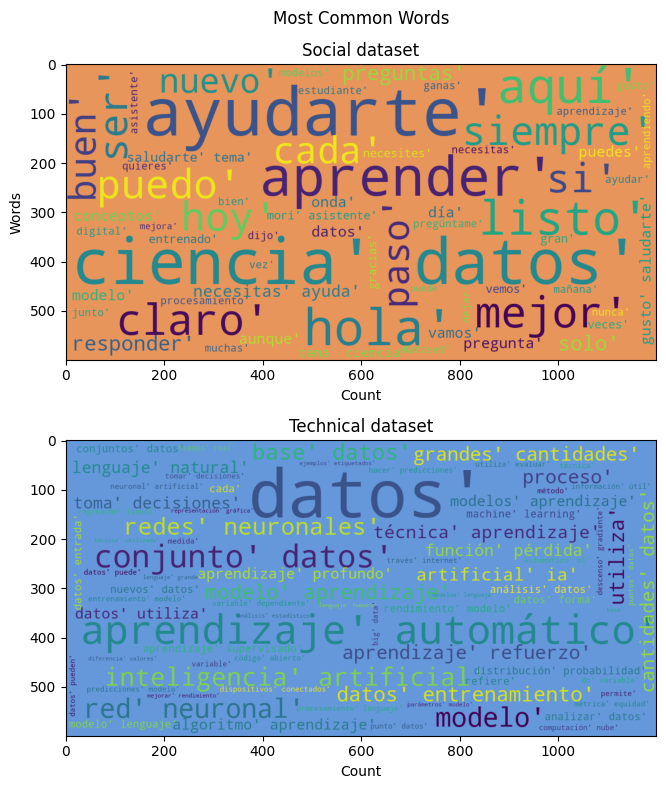

In [4]:
# Generating Corpuses
corpus_soc = [crea_corpus(df_social['output'].map(lambda oracion: tokenizer(oracion)), 'lemmatizer')]
corpus_tec = [crea_corpus(df_tecnico['output'].map(lambda oracion: tokenizer(oracion)), 'lemmatizer')]

nubes_de_palabras([corpus_soc, corpus_tec], ['#e8955b', '#6498db'], (10,8))

## Siguientes pasos

Una vez generados los datasets, técnico y social, el siguiente objetivo consiste en aplicar un ajuste fino sobre modelos de lenguaje preentrenados para desarrollar el modelo de preguntas y respuestas (Q&A) que utilizará Mori para responder preguntas relacionadas con el procesamiento de datos. Sin embargo, dado que Mori también incluye un componente conversacional basado en un dataset social independiente, es necesario implementar un mecanismo que permita clasificar la intención de la pregunta del usuario.

Este clasificador no solo permitirá determinar si la pregunta se enmarca dentro de un contexto social o técnico, sino que además posibilitará identificar el subcontexto técnico específico, como por ejemplo:

- datos
- evaluación
- aprendizaje
- estadística
- entre otros temas relevantes dentro del dominio del procesamiento de datos.

Para evitar desequilibrios en la clasificación, este análisis no considera las paráfrasis generadas. Aunque las paráfrasis aportan valor al entrenamiento al mejorar la capacidad del modelo para generalizar, también pueden desbalancear las clases si se agregan de manera no controlada, afectando la precisión de la clasificación y dando lugar a respuestas fuera del tema esperado.

La siguiente figura muestra la distribución de los contextos temáticos y la cantidad de ejemplos considerados en cada uno para el entrenamiento del modelo de clasificación. Los datos provienen tanto del dataset técnico como del social.

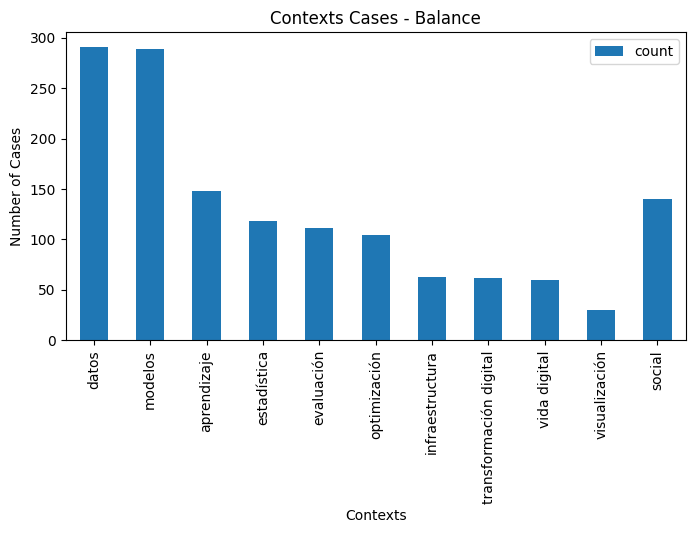

In [62]:
pd.DataFrame(pd.concat([df_tecnico.context.value_counts(), df_social.context.value_counts()])).plot.bar(figsize=(8,4), title='Contexts Cases - Balance',
                                                                                                        ylabel='Number of Cases', xlabel='Contexts');

### Procedimiento para generar el clasificador de contextos

Una vez clasificadas las preguntas y respuestas dentro de los distintos contextos temáticos, se incorpora el uso de paráfrasis en el conjunto técnico con el fin de aumentar la capacidad de generalización del modelo. Además, se integra el dataset social para incluir todos los posibles tipos de interacción dentro de un único conjunto de entrenamiento. Con este dataset unificado, se procede a entrenar un clasificador de contexto, utilizando los contextos definidos en la subsección anterior.

Para ello, se emplea un modelo ***BERT*** preentrenado, sobre el cual se implementa un ajuste fino (*fine-tuning*) utilizando la clase *BertForSequenceClassification*. Esta arquitectura permite determinar el contexto de una pregunta basándose en su estructura semántica.

De forma complementaria, se utiliza el *BertTokenizer* para codificar las entradas (preguntas del usuario) y decodificar las respuestas generadas por el modelo. Todo el proceso se ilustra en la siguiente Figura:

<h4> Diagrama del Clasificador de Contexto</h4>

<img src="img/Mori_Clasificador.png" alt="diagrama" width="350"/>



### Diagrama de funcionalidad de Mori

Una vez generado el *clasificador BERT*, se procede al entrenamiento de los modelos que conforman la solución final del asistente Mori.

Por un lado, se utiliza el dataset social para aplicar ajuste fino sobre un modelo preentrenado *T5-base* de *Google* (*Text-To-Text Transfer Transformer*), diseñado específicamente para tareas de tipo Q&A. En este caso, el fine-tuning permite al modelo aprender la relación entre preguntas sociales y sus respuestas correspondientes.

Por otro lado, el dataset técnico, enriquecido previamente con preguntas parafraseadas, se emplea para entrenar un segundo modelo *T5-base*. Sin embargo, a diferencia del enfoque social, en este caso se aplica una estrategia de ***prompt engineering*** para ayudar al modelo a entender el contexto temático de cada pregunta. La entrada al modelo se estructura de la siguiente manera:

***Entrada al modelo:*** <br>
    *"Context: {context} [SEP] Question: {question}"*

Esta estructura permite que el modelo técnico no solo relacione una pregunta con su respuesta, sino que lo haga considerando explícitamente el contexto técnico específico en el que se enmarca la consulta. Una vez entrenados ambos modelos (técnico y social), se integra la funcionalidad completa en el asistente Mori, siguiendo el flujo representado en la siguiente Figura:


<h4> Diagrama del Clasificador de Contexto</h4>

<img src="img/Mori_Chatbot.png" alt="diagrama" width="450"/>

### Implementación de Mori

Actualmente, Mori puede utilizarse de dos formas principales:

- A través de la línea de comandos (Command Prompt en Windows o terminal en Linux/Mac).

- Mediante una interfaz web interactiva, desplegada en la plataforma 🤗 Hugging Face Spaces: https://huggingface.co/spaces/tecuhtli/Mori_Bot

En ambos casos, el funcionamiento del asistente es el mismo: Mori recibe una pregunta del usuario, clasifica su intención (técnica o social), y responde utilizando el modelo adecuado. La diferencia radica únicamente en la forma de interactuar con él.

A continuación, se muestran ejemplos del uso de Mori en ambas modalidades:

#### Terminal / Command Prompt:

Interacción directa desde consola, útil para pruebas rápidas o integración en flujos de desarrollo local.

<img src="img/Mori_Terminal.png" alt="diagrama" width="980"/>

#### Plataforma Hugging Face:
    
Interfaz visual amigable que permite una experiencia conversacional más accesible, especialmente pensada para usuarios finales o presentaciones.

<img src="img/Mori_TheHuggingFace.png" alt="diagrama" width="480"/>




### Arquitectura y archivos del proyecto

Aunque este notebook tiene como objetivo principal documentar el procesamiento de datos y explicar cómo se implementa Mori, en esta subsección se presenta información complementaria sobre la estructura del proyecto, incluyendo la organización de archivos y la función de los elementos clave.

Este proyecto está compuesto por una serie de archivos y carpetas que permiten llevar a cabo tareas como el entrenamiento de modelos, la curación de datos y la ejecución del asistente personal Mori.

#### 📁 Estructura de Archivos

```text
Mori/
├── Data/
│   ├── Dataset_Social_ParafrasisTecnico_Unificado.json        ← Dataset para entrenar el Clasificador BERT
│   ├── Parafrasis_Conceptos_Curados_Manualmente_Tecnico.json  ← Dataset para entrenar a Mori Técnico
│   └── Conceptos_Curados_Manualmente_Social.json              ← Dataset para entrenar a Mori Social
│
├── Notebooks/
│   ├── TrainingDatasetGeneration.ipynb   ← Notebook para el procesamiento y curación de datos
│   └── Folders_Adicionales/              ← Funciones y datos auxiliares usados por el notebook
│
├── Models/
│   ├── mori-context-model/     ← Clasificador BERT entrenado
│   ├── mori-tecnico-model/     ← Modelo T5 fine-tuned (técnico)
│   └── mori-social-model/      ← Modelo T5 fine-tuned (social)
│
├── Scripts/
│   ├── DataGathering.py              ← Script para web scraping general y libros
│   ├── DataGathering_Wikipedia.py    ← Script para scraping en Wikipedia (manual + SerpAPI)
│   ├── Training_MoriTecnico.py       ← Script para entrenar a Mori Técnico
│   ├── Training_MoriSocial.py        ← Script para entrenar a Mori Social
│   ├── Training_MoriClassifier.py    ← Script para entrenar el Clasificador BERT
│   └── Mori_Chatbot.py               ← Script principal para ejecutar al asistente Mori

## Conclusión y recomendaciones futuras

El desarrollo de Mori representa un avance significativo hacia la creación de un asistente educativo especializado en el procesamiento de datos, apoyado en modelos de lenguaje avanzados. A través de un flujo bien estructurado, que abarca recolección, curación, clasificación e implementación de modelos, se logró diseñar un sistema capaz de distinguir entre contextos sociales y técnicos, y de responder de forma adecuada en ambos escenarios.

Gracias a la separación de modelos por tipo de interacción, y al uso de técnicas como *prompt engineering* y *generación de paráfrasis*, Mori ofrece una experiencia conversacional accesible, adaptable y técnicamente robusta.

Sin embargo, al tratarse de una versión MVP, Mori aún presenta diversas oportunidades de mejora, especialmente en lo que respecta al dataset de entrenamiento. Actualmente, el modelo ha sido entrenado con aproximadamente 1,000 conceptos diferentes. Aunque este volumen puede parecer considerable, resulta limitado frente a la amplitud y evolución constante del campo del procesamiento de datos.

Por lo tanto, se proponen las siguientes recomendaciones para una versión futura más sólida y funcional:

### Recomendaciones futuras

- Ampliar el dataset de entrenamiento, tanto en su componente social como técnico, incorporando más conceptos, definiciones y ejemplos.

- Mejorar el balance de clases: algunos contextos técnicos tienen baja representación. Generar ejemplos adicionales (reales o sintéticos) permitirá fortalecer el rendimiento del clasificador.

- Incorporar detección de intención más detallada, permitiendo diferenciar no solo el contexto (social o técnico), sino también el tipo de intención de la pregunta (por ejemplo: definición, comparación, solicitud de ejemplo, etc.).

- Realizar evaluaciones continuas con usuarios reales, para medir la calidad, utilidad y claridad de las respuestas, ajustando el comportamiento del asistente en base a retroalimentación práctica.

- Desplegar Mori en una interfaz web o API, lo cual permitirá integrarlo en plataformas educativas, expandir su alcance y evaluar su impacto en entornos reales de aprendizaje.

# FIN